In [1]:
import graphviz as gr


def draw_graph(edge_list, node_props=None, edge_props=None, graph_direction="UD"):
    """Utility to draw a causal (directed) graph"""
    g = gr.Digraph(
        graph_attr={"rankdir": graph_direction, "ratio": "0.3", 
                    'overlap':'vpsc',
                    'splines':'true',
                    'mode':'sgd',
                    'lheight':'4'},
        engine="neato",
    )

    edge_props = {} if edge_props is None else edge_props
    for e in edge_list:
        props = edge_props[e] if e in edge_props else {}
        g.edge(e[0], e[1], **props)

    if node_props is not None:
        for name, props in node_props.items():
            g.node(name=name, **props)
    return g

In [2]:
nodes = ["Economic Activity", 
         "Climate System", 
         "Disasters Severity", 
         "Disaster Frequency",
         "Co2",
         "Ocean Temperature",
         "GDP",
         "Disasters"]

edges = [
    ("Economic Activity", "Climate"),
    ("Climate", "Economic Activity"),
    ("Climate", "Disaster Severity"),
    ("Climate", "Disaster Frequency"),
    ("Geography", "Disaster Severity"),
    ("Geography", "Disaster Frequency"),
    ("Disaster Severity", 'Disasters'),
    ("Disaster Frequency", 'Disasters'),
    ('Disasters', "Economic Activity"),
    ("Economic Activity", "GDP"),
    ("Economic Activity", "Population"),
    ("Economic Activity", "Disaster Severity"),
    ("Climate", "Co2"),
    ('Climate', "Ocean Temperature")

]
edge_props = {}
node_props = {"Economic Activity": {'style':'dashed'},
              "Climate": {'style': 'dashed'},
              "Disaster Severity": {'style':'dashed'},
              "Disaster Frequency": {'style': 'dashed'}}

g = draw_graph(edges, edge_props=edge_props, node_props=node_props, graph_direction="LR")

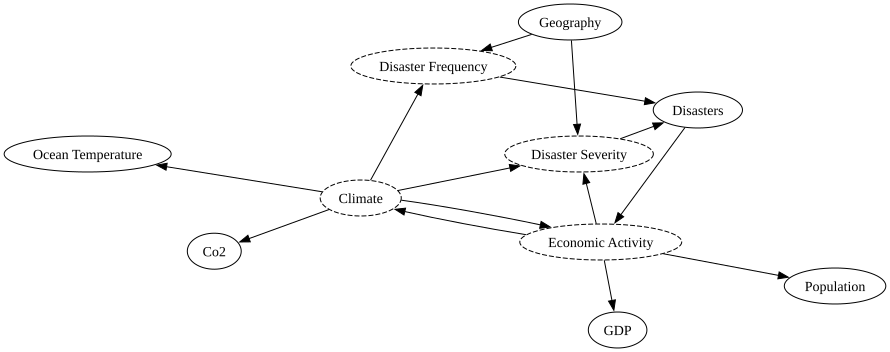

In [3]:
g

In [29]:
g.render('causal_graph', directory='/Users/jessegrabowski/Downloads', format='png')

'/Users/jessegrabowski/Downloads/causal_graph.png'

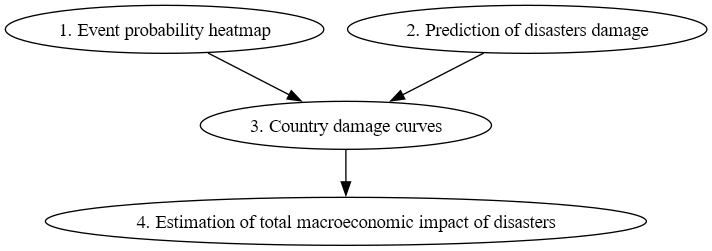

In [20]:
# Dag plot
from graphviz import Digraph
from IPython.display import Image
dot = Digraph(comment='gen_model')

dot.node('A', "1. Event probability heatmap")

dot.node('B', "2. Prediction of disasters damage")
dot.node('C', "3. Country damage curves")
dot.node('D', "4. Estimation of total macroeconomic impact of disasters")

dot.edges(["AC",'BC', 'CD'])
img = Image(dot.pipe(format='png'))
img

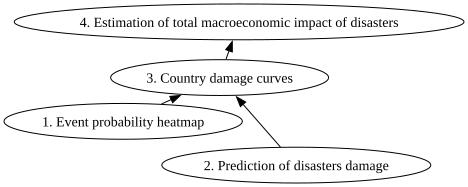

In [17]:
nodes = ["1. Event probability heatmap", 
         "2. Prediction of disasters damage", 
         "3. Country damage curves", 
         "4. Estimation of total macroeconomic impact of disasters"]

edges = [
    ("1. Event probability heatmap", "3. Country damage curves"),
    ("2. Prediction of disasters damage", "3. Country damage curves"),
    ("3. Country damage curves", "4. Estimation of total macroeconomic impact of disasters"),]


edge_props = {}
node_props = {}

g_2 = draw_graph(edges, edge_props=edge_props, node_props=node_props, graph_direction="LR")
g_2

In [30]:
import preliz as pz
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import root_scalar
from scipy.stats import ecdf
import arviz as az

def obj(x, RY, sf):
    return 1 / max(sf(x), np.spacing(1)) - RY


# sample trace data from a known distribution
d = stats.gamma(a=2, scale=1/10)
fake_idata = d.rvs((6, 1000))

sf = stats.ecdf(fake_idata.ravel()).sf.evaluate

res = root_scalar(obj, 
                  bracket = [fake_idata.min(), fake_idata.max()],
                  args=(100, sf),
                  method='brentq')

print(res.root)
print(d.ppf(0.99))

0.6588899718453581
0.6638352067993811


In [31]:
d.ppf(0.99)

0.6638352067993811

In [32]:
res

      converged: True
           flag: converged
 function_calls: 62
     iterations: 61
           root: 0.6588899718453581
         method: brentq

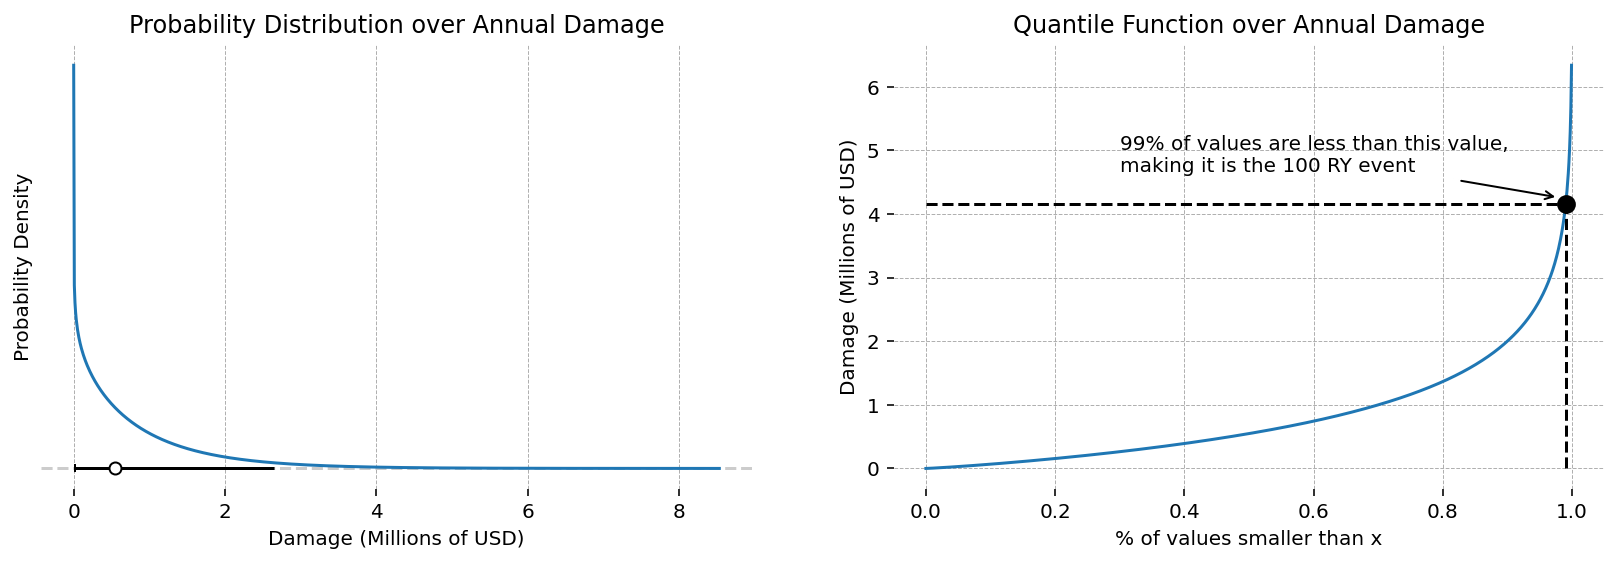

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=144)
params = pz.maxent(pz.Gamma(), lower=0, upper=1, mass=0.7, plot=False).params_dict
d = pz.Gamma(**params)
d.plot_pdf(ax=ax[0], legend=False, interval='hdi', levels=(0.05, 0.95), pointinterval=True)
d.plot_ppf(ax=ax[1], legend=False)
ax[0].set(title = 'Probability Distribution over Annual Damage', 
          xlabel='Damage (Millions of USD)',
          ylabel='Probability Density')
ax[1].set(title = 'Quantile Function over Annual Damage',
          xlabel='% of values smaller than x', 
          ylabel='Damage (Millions of USD)')

ax[1].vlines(0.99, 0, d.ppf(0.99), ls='--', color='k')
ax[1].hlines(d.ppf(0.99), 0, 0.99, ls='--', color='k')
ax[1].scatter(0.99, d.ppf(0.99), c='k', s=70, zorder=100)

ax[1].annotate('99% of values are less than this value,\nmaking it is the 100 RY event',
               xy = (0.99 - 0.01, d.ppf(0.99) + 0.1),
               xytext = (0.3, d.ppf(0.99) + 0.5),
               arrowprops={'arrowstyle':'->'})

for ax in fig.axes:
    [spine.set_visible(False) for spine in ax.spines.values()]
    ax.grid(ls='--', lw=0.5)
    
    
plt.savefig('/Users/jessegrabowski/Downloads/example_damage.png')

In [34]:
cdf = ecdf(d.rvs(10_000))

[Text(0.5, 0, 'Damage (Million USD)'),
 Text(0.5, 1.0, 'Joint Probably of Disaster and Damage'),
 (-0.5, 100.0)]

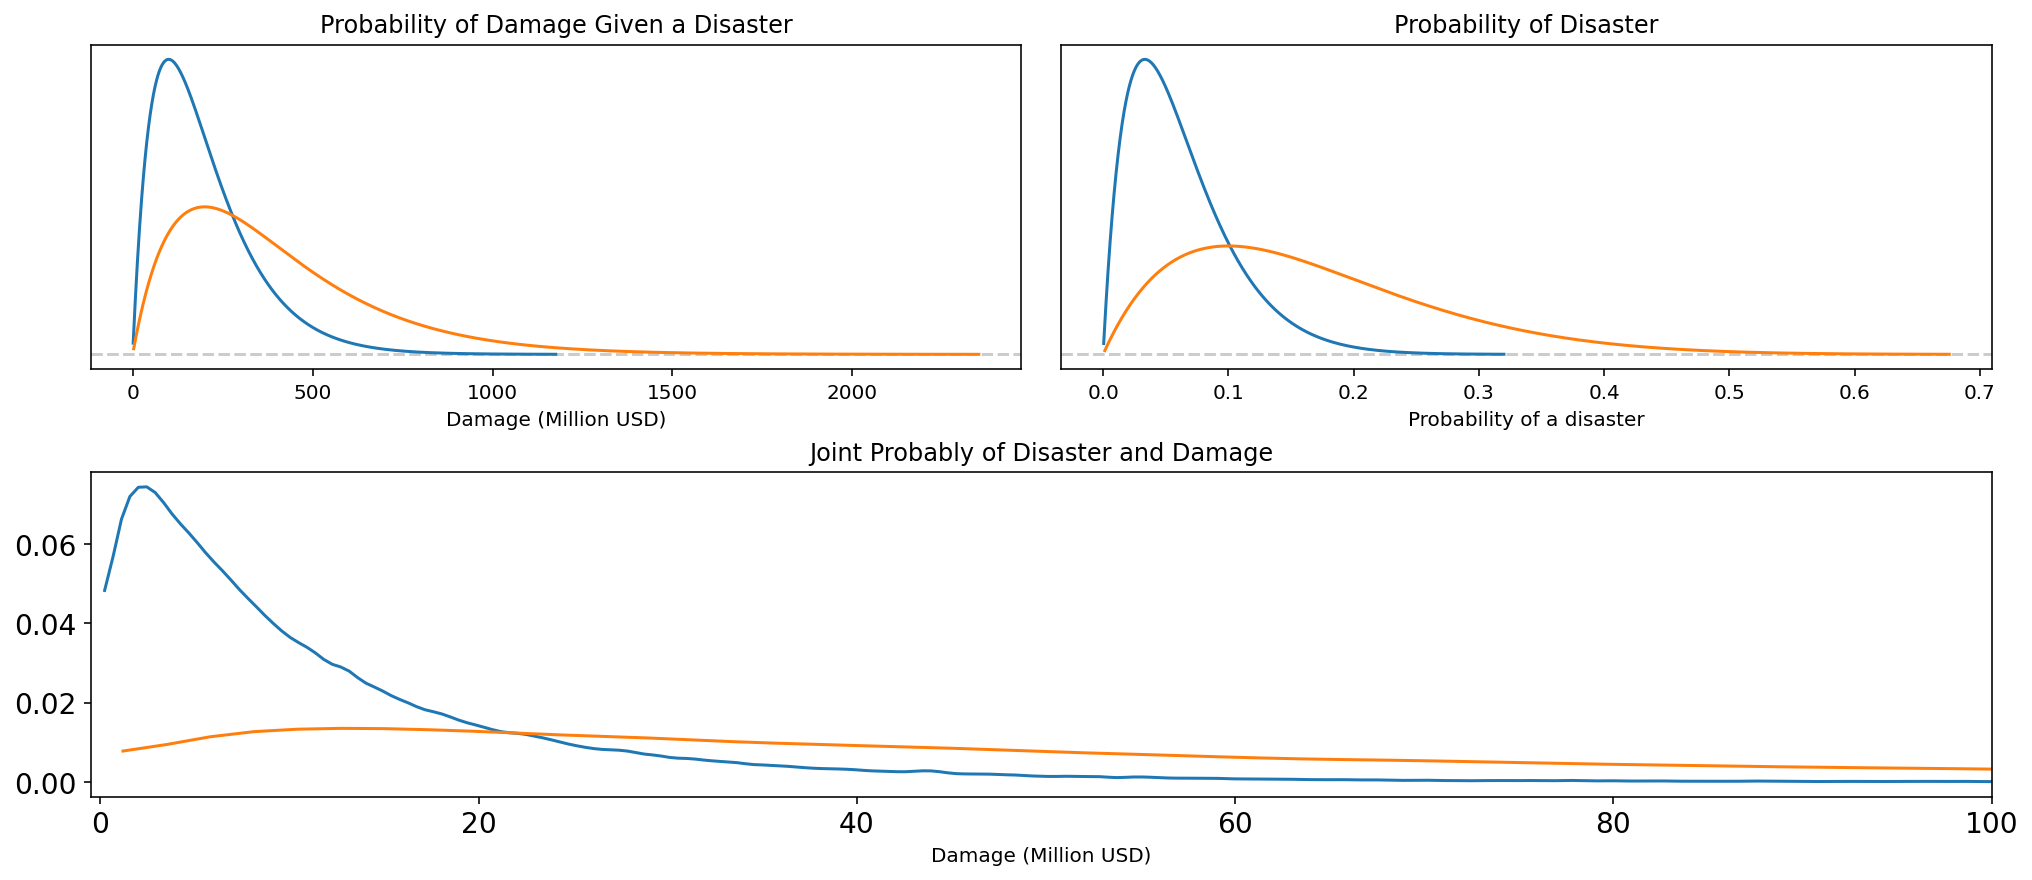

In [35]:
fig = plt.figure(figsize=(14, 6), dpi=144, layout='constrained')
gs = plt.GridSpec(ncols=2, nrows=4, figure=fig)

damage_ax  = fig.add_subplot(gs[:2, 0])
prob_ax    = fig.add_subplot(gs[:2, 1])
product_ax = fig.add_subplot(gs[2:, :])

damage_ds = [pz.Gamma(2, 1e-2), pz.Gamma(2, 5e-3)]
prob_ds   = [pz.Beta(alpha=2, beta=30), pz.Beta(alpha=2, beta=10)]

colors = plt.color_sequences['tab10'][:4]
for damage_d, prob_d, c in zip(damage_ds, prob_ds, colors):
    damage_d.plot_pdf(ax=damage_ax, legend=False, color=c)
    prob_d.plot_pdf(ax=prob_ax, legend=False, color=c)
    az.plot_kde(damage_d.rvs(100_000) * prob_d.rvs(100_000), ax=product_ax, plot_kwargs={"c":c})

damage_ax.set(xlabel='Damage (Million USD)', title='Probability of Damage Given a Disaster')
prob_ax.set(xlabel='Probability of a disaster', title='Probability of Disaster')
product_ax.set(xlabel='Damage (Million USD)', title='Joint Probably of Disaster and Damage',
               xlim=(-0.5, 100))